In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, plot_time_bands_median
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()

In [2]:
pkl_path = Path("results/admm_runs_rl/admm_results_2026-01-11_21-02-28.pkl")  # adjust to your file
with pkl_path.open("rb") as f:
    data = pickle.load(f)

pkl_path = Path("results/admm_runs_18_01/admm_results_2026-01-18_00-07-07.pkl")  # adjust to your file
with pkl_path.open("rb") as f:
    data_18_01 = pickle.load(f)

df_singles = pd.read_csv("results/admm_runs_rl/results_nn_pyomo_single.csv")
df_singles_18_01 = pd.read_csv("results/admm_runs_18_01/results_nn_pyomo_single.csv")


In [3]:
df_singles

,regularization,times_elapsed,mse_coll_ode,mse_coll_ode_test
0,1,145.009997,0.092977,0.100134
1,1,133.665107,0.021154,0.355737
2,1,156.564767,0.091836,2.695814
3,1,150.457997,0.035014,0.377103
4,1,130.863472,0.130103,0.068344
5,1,146.230266,0.052208,0.158861
6,1,146.828048,0.003937,6.096047
7,1,152.109184,0.114982,0.824942
8,1,146.281616,0.039454,0.302092
9,1,145.532691,0.155920,1.027970


In [4]:
df = pd.DataFrame(data)
df.head()

df_18_01 = pd.DataFrame(data_18_01)
df_18_01 = df_18_01.T
df_18_01.head()

,primal_residual,mae_collocation,mse_collocation,mae_diffrax,mse_diffrax,iter,time_elapsed,mse_collocation_test
2015-01-15,"[215.40531850554967, 215.40530485964698, 8.750...",[],"[4.239828133047697, 4.239829121896776, 2.05021...",[],"[4.250564180519745, 4.424104823962979, 2.11370...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[33.13462042808533, 34.358760356903076, 39.086...","[5.087412741436122, 5.087414462339645, 5.33990..."
2015-01-20,"[210.81604529189318, 210.81604670538516, 4.849...",[],"[4.829481911496645, 4.8294772382822515, 4.8724...",[],"[16.393425694291913, 17.14530160613246, 22.251...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[27.99281620979309, 29.110186100006104, 35.424...","[12.39746659212361, 12.397479754503145, 12.816..."
2015-01-25,"[235.95522972952836, 235.95522197287514, 6.809...",[],"[5.012156665560832, 5.0121578564463665, 1.8434...",[],"[48.28015352671668, 45.92178701093462, 26.9113...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[25.31655216217041, 26.385462284088135, 31.393...","[11.434030110470166, 11.434028888250253, 10.92..."
2015-01-30,"[212.02135506635025, 212.02135555421307, 4.580...",[],"[3.050985030570114, 3.050985026464072, 3.00138...",[],"[30.086900584758794, 29.704862933159063, 26.17...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[23.94003129005432, 24.978530168533325, 28.852...","[10.166016241948633, 10.166016434704693, 10.00..."
2015-02-04,"[220.84448000206746, 220.84446926882524, 7.632...",[],"[4.01166321782746, 4.0116626909479, 1.50719735...",[],"[3.9869308397555305, 4.053536626393889, 1.4843...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[27.355059385299683, 28.531994581222534, 35.28...","[5.580480598068164, 5.580481209245035, 2.77654..."


In [5]:
df.head()

,primal_residual,mse_diffrax,iter,time_elapsed,seed,mse_test_diffrax,mse_collocation_train,mse_collocation_test
0,"[39.7558266922021, 39.75582669172841, 78.17277...","[3.2794590776616297, 3.2794590777503996, 3.926...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[22.463560342788696, 23.189019680023193, 44.70...",7458651,"[3.082901244219896, 3.0829012441935357, 3.5606...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,"[46.315620649872734, 46.315620647445776, 90.29...","[212.26145107951547, 212.82083220627175, 29.59...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[22.857406616210938, 23.587087631225586, 48.04...",1241253,"[2957.0863143357906, 2957.086296609875, 1262.1...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,"[38.52717132632789, 38.52717132242447, 74.8303...","[5.494156407118792, 5.494156449008841, 31.4644...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[20.810786485671997, 21.648167610168457, 33.75...",3798560,"[4.950972800866428, 4.950972767886427, 20.7525...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,"[43.064460879559675, 43.06446081504591, 86.386...","[871.9714982474848, 871.9705064059796, 1138.71...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[19.62995934486389, 20.514219284057617, 81.707...",7752020,"[1127.6547696846699, 1127.6539037787506, 1255....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,"[41.04169266216962, 41.0416926621712, 79.70746...","[10.548258265683893, 10.548258265694537, 260.2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[20.850682973861694, 21.701992511749268, 34.22...",2973620,"[12.359826856862702, 12.359826856875715, 178.4...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [6]:
df_18_01["seed"] = df_18_01.index.astype(str)


In [7]:
list_cols = [
    "primal_residual",
    "mse_diffrax",
    "iter",
    "time_elapsed",
    "mse_test_diffrax",
    "mse_collocation_train",
    "mse_collocation_test",
]

df_long = (
    df
    .assign(**{c: df[c].apply(list) for c in list_cols})  # in case some are arrays
    .explode(list_cols, ignore_index=True)
)

list_cols = [
    "primal_residual",
    "mse_diffrax",
    "iter",
    "time_elapsed",
    "mse_collocation",
    "mse_collocation_test",
]

df_long_18_01 = (
    df_18_01
    .assign(**{c: df_18_01[c].apply(list) for c in list_cols})  # in case some are arrays
    .explode(list_cols, ignore_index=True)
)


In [8]:
df_long_18_01.groupby("seed").last()

,primal_residual,mae_collocation,mse_collocation,mae_diffrax,mse_diffrax,iter,time_elapsed,mse_collocation_test
seed,,,,,,,,
2015-01-15,0.725309,[],0.212081,[],5.070262,49,71.500072,5.519645
2015-01-20,0.933246,[],0.136781,[],74.202379,49,71.370458,2.050853
2015-01-25,0.942556,[],0.087518,[],78.956306,49,69.521233,8.378672
2015-01-30,0.591725,[],0.357071,[],18.976524,49,69.780001,9.674916
2015-02-04,0.816572,[],5.243759,[],5.966935,49,81.177448,3.238737
2015-02-09,0.717384,[],0.162952,[],528.599002,49,76.336145,2.066934
2015-02-14,0.985283,[],0.540313,[],0.613695,49,79.909777,12.806151
2015-02-19,1.076423,[],2.619223,[],9.698626,49,85.818064,5.064391
2015-02-24,0.59926,[],0.206061,[],33.216359,49,94.544638,2.912549


In [9]:
df_singles_18_01

,regularization,times_elapsed,mse_odeint,mse_coll_ode,mse_odeint_test,mse_coll_ode_test
0,1,80.190787,205.277844,0.086237,39.294677,0.110151
1,1,80.098166,8.475229,0.017021,13.853389,1.474249
2,1,80.364921,39.344845,0.111310,164.274817,2.611774
3,1,80.359295,816.562773,0.065234,515.022884,0.475477
4,1,80.186264,2682.460593,0.060384,1564.789403,0.076737
5,1,80.249382,3402.281468,0.090872,986.992101,0.123105
6,1,80.381837,0.020916,0.004228,5.114702,5.147990
7,1,80.272185,654.325434,0.110903,279.146359,1.056762
8,1,80.281405,1787.630973,0.046488,585.538945,0.379575
9,1,80.147677,9.785969,0.094968,10.648584,0.870404


In [10]:
df_singles_18_01 = df_singles_18_01.rename(columns={"times_elapsed": "time_elapsed", "mse_coll_ode": "mse_diffrax", "mse_coll_ode_test": "mse_test_diffrax"})

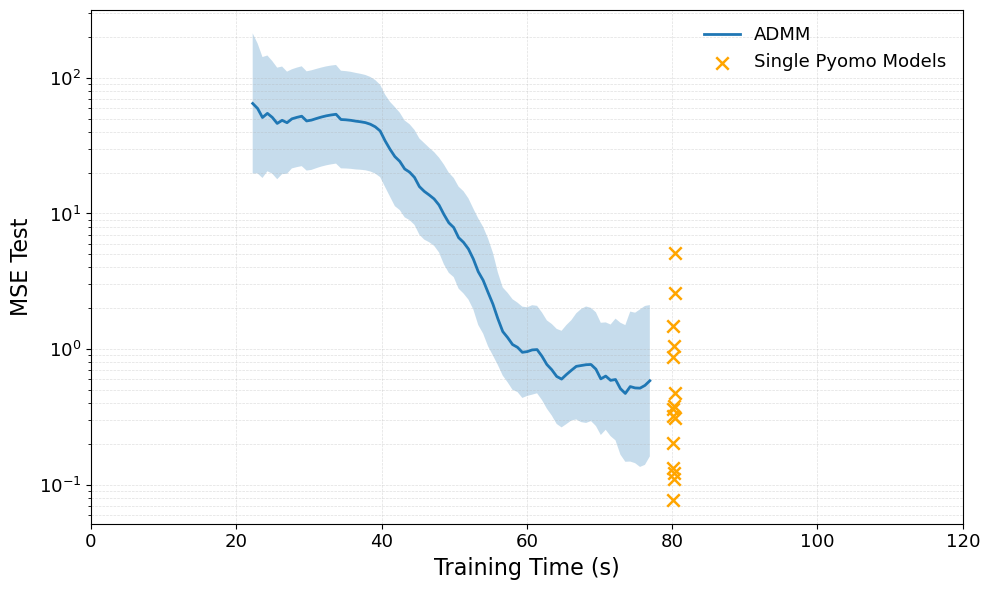

<Axes: xlabel='Training Time (s)', ylabel='MSE Test'>

In [14]:
plot_time_bands(
    {"ADMM":df_long},
    y_col="mse_test_diffrax",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 120),
    extrapolate=False,
    y_label="MSE Test",
    points_df=df_singles_18_01,
    points_size = 80,
    points_label="Single Pyomo Models"
)

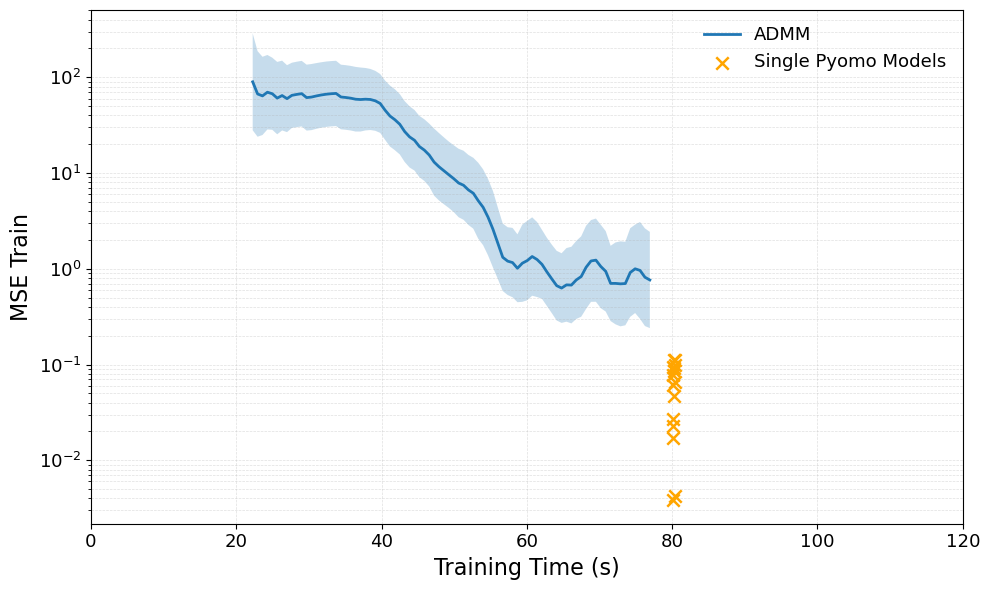

<Axes: xlabel='Training Time (s)', ylabel='MSE Train'>

In [13]:
plot_time_bands(
    {"ADMM":df_long},
    y_col="mse_diffrax",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 120),
    extrapolate=False,
    y_label="MSE Train",
    points_df=df_singles_18_01,
    points_size = 80,
    points_label="Single Pyomo Models"
)